### On commence par importer nos bibliothèques
- matplotlib pour dessiner
- random pour les points aléatoires de la simulation Monte Carlo

In [1]:
import matplotlib.pyplot as plt
import random as rm

## Comment ça marche :
On travaillera sur un plan du système de coordonnées cartésiennes.

On dessine en premier un cercle de centre $O(0; 0)$ et de rayon $r=1$. 
On note $A$ l'aire du disque.

$A = \pi r^2$

$A = \pi \times 1^2  $

$A = \pi$

---

On a donc un disque d'aire $\pi$

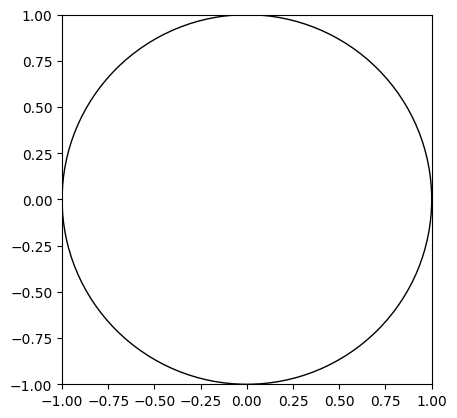

In [2]:
fig, ax = plt.subplots() #on crée un plan cartésien
ax.set_aspect('equal')

cercle = plt.Circle((0, 0), 1, fill=False) #on commence par créer un cercle de rayon 1 centré en (0,0)
ax.add_patch(cercle) #on ajoute le cercle au plan cartésien

ax.set_xlim(-1, 1) #on fixe les limites de l'axe des x et des y à -1 et 1, se sera notre carré de référence
ax.set_ylim(-1, 1)

plt.show() #on affiche le cercle et le carré de référence

## Comment procéder :

Comme vous l'avez remarqué, notre cercle est au centre du plan et inscrit dans un carré. Il est donc dans un carré de côté 2 ($c = 2 $).

On note $A'$ l'aire du carré.

$A' = c^2$

$ A' = 2^2 $

$ A' = 4 $

### 1) On place aléatoirement des points dans le carré.

On utilise une distribution uniforme. Pour faire simple, les points sont répartis uniformément dans le carré.

Soit $P$ la probabilité théorique qu'un point tiré au hasard appartienne à notre disque.

$ P = \frac {\text {Aire du disque}} {\text {Aire du carré}} $

$$ P = \frac {A}{A'}$$

$$ P = \frac {\pi}{c^2}$$

$$ P = \frac {\pi}{4}$$

$$\Leftrightarrow  \pi = 4P $$


On a donc :

 $\pi = 4P $

### 2.1) Loi des grands nombres.

Notre simulation de Monte Carlo marche surtout grâce à la loi des grands nombres. 

D'après la loi des grands nombres : fréquence observée d’un événement converge vers sa probabilité théorique lorsque le nombre de tirages tend vers l’infini.

En d'autres termes, plus notre nombre de tirages est grand, plus notre valeur $4P$ se rapprochera de $\pi$.

### 2.2) Compter les points.

Nous connaissons le nombre total de points, défini par $N$.

Le véritable défi est de connaître le nombre de points dans notre disque de rayon $r$, et tout cela, sur un plan cartésien.

Or, d'après l'équation cartésienne du cercle :

Pour tout point $M(x, y)$ et un cercle de centre $O(a, b)$ et de rayon $r$. 

Si $(x-a)^2 + (y-b)^2 = r^2 $ alors le point $M$ est sur le cercle.

Plus simplement dans notre situation :

```python
n = 0

if (x**2)+(y**2) <= r**2 :
    n += 1 
```

### 3) Implémentation.

On définit :

 - $N$ le nombre total de points générés dans le carré

 - $n$ le nombre de points appartenant au disque.

In [3]:
N = 10000 #On choisit nombre total de points à générer aléatoirement
n = 0 #On initialise le nombre de points qui tombent dans le cercle à 0

Pour générer des points aléatoirement on utilise la fonction ```rm.uniform(a, b)```. Celle-ci va nous générer un nombre aléatoire dans l'intervalle $[a; b]$.

In [4]:
for i in range(N): #On initialise une boucle "for" pour générer N points aléatoires
  
  #On génère les coordonnées aléatoires x et y de nos point dans le carré de référence
  x = rm.uniform(-1, 1)
  y = rm.uniform(-1, 1)

Pour afficher les points dans notre carré, on utilise la fonction ```plt.scatter(x, y)``` de matplotlib à la fin de la boucle. Celle-ci affichera le point à partir de ses coordonnées $(x, y)$.

In [ ]:
#On affiche les points générés aléatoirement, définis par leur coordonnées x et y, leur couleur et leur taille
plt.scatter(x, y, s=0.75, color="red")

Pour afficher la valeur approximatif de $\pi$, on se servira de la fonction ```print()```.

In [5]:
p = n/N #On calcule la proportion de points qui tombent dans le cercle par rapport au nombre total de points générés
pi = 4*p #On estime la valeur de pi en multipliant la proportion par 4, car le rapport entre l'aire du cercle et celle du carré est de 4:1

print(f"Pi est environ égale à : {pi}") 

Pi est environ égale à : 0.0


### 4) On compile le tout.

Pi est environ égale à : 3.1472


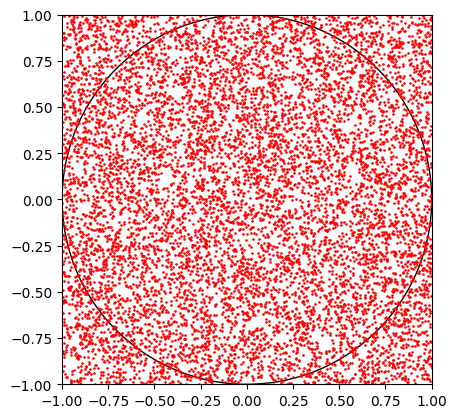

In [15]:
cercle = plt.Circle((0, 0), 1, fill=False)

#Paramètrage du plan cartésien

fig, ax = plt.subplots()

ax.set_aspect('equal')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

ax.add_patch(cercle)

N = 10000
n = 0

#On intialise notre boucle for

for i in range(N):
  x = rm.uniform(-1, 1)
  y = rm.uniform(-1, 1)

  if x**2 + y**2 < 1 :
    n+=1

  plt.scatter(x, y, s=0.75, color="red")

#Calcul de pi à partir de la proportion de points qui tombent dans le disque

p = n/N
pi = 4*p

print(f"Pi est environ égale à : {pi}")

plt.show()

## Et voilà comment calculer $\pi$ avec la méthode Monte Carlo sur Python !

### 5) Comment aller plus loin ?

Pour aller plus loin on peut créer une fonction qui nous permettra d'estimer $\pi$ à partir de $N$ points.

### 5.1) ```estimation_pi(N : int)```

Notre première fonction approximera $\pi$ sans graphique. Le principe reste le même.

On génère des points et on les positionne aléatoirement. Si ses coordonnées respectent cette condition : ```x**2 + y**2 <= 1```, alors le point appartient au disque. La valeur de sortie de notre fonction sera l'estimation de $\pi$, d’où : 

```pi = 4*(n/N)```

Cette fonction est facile à calculer car il n'y a pas de graphique à dessiner. Elle est donc bien plus rapide et compacte.

In [6]:
def estimation_pi(N : int):
    n = 0

    for i in range(N):
        x = rm.uniform(-1, 1)
        y = rm.uniform(-1, 1)

        if x**2 + y**2 <= 1 :
            n+=1

    p = n/N
    pi = 4*p

    print(f"Pi est environ égale à : {pi}")

In [11]:
estimation_pi(15000)

Pi est environ égale à : 3.146933333333333


### 5.1) ```estimation_pi_graph(N : int)```

Contrairement à l'autre fonction, celle-ci affichera le graphique. Cela nous permettra de mieux visualiser le résultat.

Le principe reste toujours le même que pour la première démonstration. À la fin, notre fonction renverra une estimation de $\pi$ mais aussi un affichage graphique.

In [12]:
def estimation_pi_graph(N : int):

    cercle = plt.Circle((0, 0), 1, fill=False)

    fig, ax = plt.subplots()

    ax.set_aspect('equal')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)

    ax.add_patch(cercle)

    n = 0

    for i in range(N):
        x = rm.uniform(-1, 1)
        y = rm.uniform(-1, 1)

        if x**2 + y**2 < 1 :
            n+=1

        plt.scatter(x, y, s=0.75, color="red")

    p = n/N
    pi = 4*p

    print(f"Pi est environ égale à : {pi}")

    plt.show()

Pi est environ égale à : 3.1504


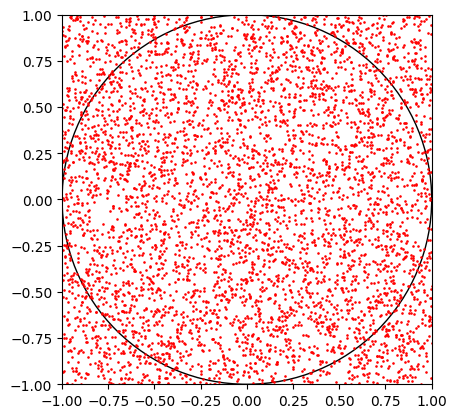

In [14]:
estimation_pi_graph(5000)